# 11 — LSTM: เตรียมข้อมูล (sliding window 48 ชม. → 24 ชม.)

ข้อมูลมาจาก `python -m src.sequences` ใช้เฉพาะ 2023–2024 โดยปี 2025 ถูกกรองออกตั้งแต่อ่านไฟล์ raw

- **Input (มีให้ใช้ตอนใช้งานจริงเท่านั้น):** features 23 ตัว (Open-Meteo + เวลา/ตำแหน่ง)
  - ย้อนหลัง 48 ชม. (t−47…t) ตอนใช้งานจริงดึงจาก Open-Meteo `past_days`
  - 24 ชม. ข้างหน้า (t+1…t+24) เป็น covariate จากพยากรณ์ Open-Meteo
  - **ไม่มีค่า NASA POWER เป็น input** (`check_inputs()`)
- **Target:** CMF_UVI ของ t+1…t+24 (mask ชั่วโมงที่ `uvi_clear < 0.5`) แล้วแปลงเป็น UVI = `uvi_clear` × CMF
- **แบ่งตามเวลา:** train = target ทั้งหมดอยู่ในปี 2023, dev = target ทั้งหมดอยู่ในปี 2024 (window ที่คร่อมปีถูกตัดทิ้ง) ส่วน scaler ใช้สถิติจากปี 2023 เท่านั้น

⚠️ covariate "พยากรณ์" ในข้อมูลย้อนหลังเป็นค่าวิเคราะห์ (archive) ของ Open-Meteo ทุกโมเดลที่เทียบจึงได้พยากรณ์สมบูรณ์เหมือนกัน

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().resolve().parents[1]  # notebooks/ -> source_code/ -> Final-Project/
sys.path.insert(0, str(ROOT / "source_code"))

FIG_DIR = ROOT / "docs" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# reference palette (dataviz skill): fixed categorical order, recessive axes
C_OM, C_NASA, C_THIRD = "#2a78d6", "#eb6834", "#1baf7a"
INK, INK2, MUTED, GRID = "#0b0b0b", "#52514e", "#898781", "#e6e5e1"
plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": MUTED, "axes.labelcolor": INK2, "text.color": INK,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "lines.linewidth": 2, "legend.frameon": False, "figure.dpi": 100,
})


def save(fig, name):
    """Save a figure to docs/figures at 150 dpi."""
    fig.savefig(FIG_DIR / name, dpi=150, bbox_inches="tight")

In [2]:
import json

from src.features import FEATURES
from src.sequences import SEQ_DIR, SPEC_PATH, load_grid, load_windows, make_windows
from src.splits import load_model_data

spec = json.loads(SPEC_PATH.read_text(encoding="utf-8"))
train = load_windows(SEQ_DIR / "seq_v1_train.npz")
dev = load_windows(SEQ_DIR / "seq_v1_dev.npz")
for name, w in [("train", train), ("dev", dev)]:
    t = pd.DatetimeIndex(w["origin_time"])
    print(f"{name}: {len(w['y'])} windows, origins {t.min()} -> {t.max()}, "
          f"X_past {w['X_past'].shape}, X_future {w['X_future'].shape}, "
          f"valid target hours {int(w['mask'].sum())} ({w['mask'].mean():.1%})")

train: 8540 windows, origins 2023-01-03 00:00:00+00:00 -> 2023-12-30 23:00:00+00:00, X_past (8540, 48, 23), X_future (8540, 24, 23), valid target hours 87032 (42.5%)
dev: 8761 windows, origins 2023-12-31 23:00:00+00:00 -> 2024-12-30 23:00:00+00:00, X_past (8761, 48, 23), X_future (8761, 24, 23), valid target hours 89217 (42.4%)


## 1. ตรวจความสอดคล้อง: ค่ากลางวันใน grid ต้องตรงกับ `train.parquet` (วัน 5)

In [3]:
grid = load_grid()
day = load_model_data()
m = grid.merge(day[["time_utc", *FEATURES, "cmf_uvi"]], on="time_utc", suffixes=("", "_d5"))
diff = {f: float(np.nanmax(np.abs(m[f] - m[f"{f}_d5"]))) for f in [*FEATURES, "cmf_uvi"]}
print(f"matched daytime rows: {len(m)} of {len(day)}")
print("max |grid - train.parquet| over all features and cmf_uvi:", max(diff.values()))
print("gap hours in grid (missing inputs):", int(grid[FEATURES].isna().any(axis=1).sum()))

matched daytime rows: 7438 of 7438
max |grid - train.parquet| over all features and cmf_uvi: 0.0
gap hours in grid (missing inputs): 6


## 2. ตัวอย่าง window หนึ่งชุด (dev)

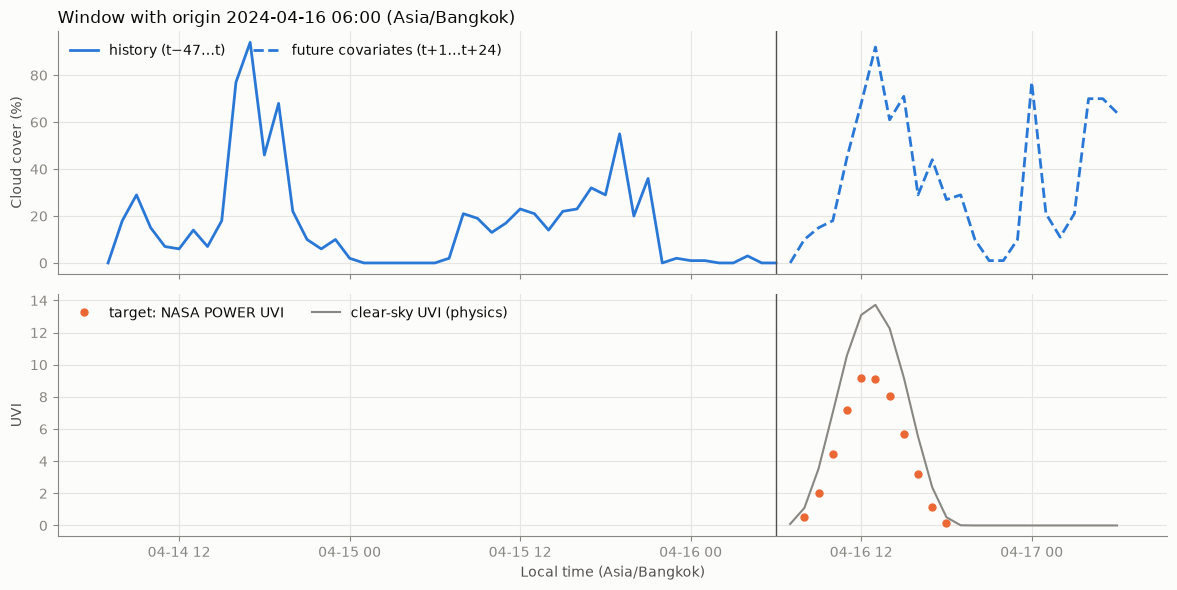

In [4]:
k = int(np.argmax(pd.DatetimeIndex(dev["origin_time"]) >= pd.Timestamp("2024-04-15 23:00", tz="UTC")))
origin = pd.Timestamp(dev["origin_time"][k]).tz_convert("Asia/Bangkok")
mu, sd = np.array(spec["scaler"]["mean"]), np.array(spec["scaler"]["std"])
j_kt, j_cc = FEATURES.index("om_kt"), FEATURES.index("cloud_cover")
past_t = origin + pd.to_timedelta(np.arange(-47, 1), unit="h")
fut_t = origin + pd.to_timedelta(np.arange(1, 25), unit="h")
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
for arr, tt, ls, lab in [(dev["X_past"][k], past_t, "-", "history (t−47…t)"),
                         (dev["X_future"][k], fut_t, "--", "future covariates (t+1…t+24)")]:
    axes[0].plot(tt, arr[:, j_cc] * sd[j_cc] + mu[j_cc], color=C_OM, ls=ls, label=lab)
axes[0].axvline(origin, color=INK2, lw=1)
axes[0].set_ylabel("Cloud cover (%)")
axes[0].set_title(f"Window with origin {origin:%Y-%m-%d %H:%M} (Asia/Bangkok)", loc="left")
axes[0].legend(loc="upper left", ncol=2)
uvi_t = dev["y"][k] * dev["uvi_clear"][k]
msk = dev["mask"][k]
axes[1].plot(fut_t[msk], dev["nasa_uvi"][k][msk], "o", color=C_NASA, ms=5, label="target: NASA POWER UVI")
axes[1].plot(fut_t, dev["uvi_clear"][k], color=MUTED, lw=1.5, label="clear-sky UVI (physics)")
axes[1].axvline(origin, color=INK2, lw=1)
axes[1].set_ylabel("UVI")
axes[1].legend(loc="upper left", ncol=2)
axes[1].set_xlabel("Local time (Asia/Bangkok)")
fig.tight_layout()
save(fig, "lstm_window_example.png")

## 3. Baseline บน dev 2024 (ก่อนมี LSTM)

,baseline,n_target_hours,uvi_mae,uvi_rmse,uvi_r2,uvi_bias,vh_recall,vh_precision,extreme_recall
0,"B1 XGBoost (day-8 config, fit 2023) + Open-Met...",89217,0.450,0.707,0.944,0.062,0.831,0.793,0.113
1,B2 Open-Meteo uv_index,89217,1.162,1.658,0.694,-0.090,0.617,0.753,0.000


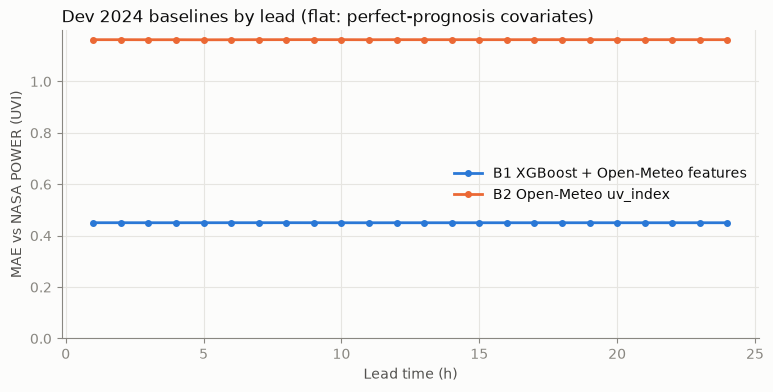

In [5]:
base = pd.read_csv(ROOT / "docs" / "lstm_baseline_dev_2024.csv")
lead = pd.read_csv(ROOT / "docs" / "lstm_baseline_by_lead_dev_2024.csv", index_col=0)
display(base.round(3))
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(lead.index, lead["B1"], color=C_OM, marker="o", ms=4, label="B1 XGBoost + Open-Meteo features")
ax.plot(lead.index, lead["B2"], color=C_NASA, marker="o", ms=4, label="B2 Open-Meteo uv_index")
ax.set_xlabel("Lead time (h)")
ax.set_ylabel("MAE vs NASA POWER (UVI)")
ax.set_ylim(0, None)
ax.set_title("Dev 2024 baselines by lead (flat: perfect-prognosis covariates)", loc="left")
ax.legend(loc="center right")
save(fig, "lstm_baseline_by_lead.png")

## สรุป

- **ตาราง grid:** รายชั่วโมงครบ 2023–2024 (17,543 ชม.) มีชั่วโมงที่ input หาย 6 ชม. และ window ที่คร่อมชั่วโมงเหล่านั้นถูกข้าม ค่ากลางวันตรงกับ `train.parquet` ของวัน 5 **ทุกค่า** (7,438 แถว ต่างกันสูงสุด 0.0)
- **Window:** train 8,540 ชุด (target ปี 2023) และ dev 8,761 ชุด (target ปี 2024) แต่ละชุดคือ input อดีต 48 × 23 + covariate อนาคต 24 × 23 และ target 24 ชม. ในจำนวนนี้ 42 % ของชั่วโมง target เป็นกลางวัน (ส่วนที่เหลือถูก mask)
- **Baseline บน dev 2024 (ทุก lead):**
  - B1 XGBoost + features Open-Meteo: MAE **0.450** UVI, recall ≥ สูงมาก 0.83, recall รุนแรงมาก 0.11
  - B2 Open-Meteo `uv_index`: MAE 1.162
  - ค่าคงที่ทุก lead เพราะ covariate ในข้อมูลย้อนหลังเป็นค่าวิเคราะห์ ไม่ใช่พยากรณ์จริง
- **เกณฑ์วัน 12 ถูกประกาศใน ROADMAP ก่อนฝึก LSTM:** LSTM ต้องชนะ B1 บน dev 2024 (MAE ต่ำกว่า **> 0.02** และ recall ≥ สูงมาก ลดลง **≤ 0.03**) ถ้าไม่ผ่านให้ใช้ XGBoost ในแอป
- **ข้อจำกัด:** input อนาคตเป็นพยากรณ์สมบูรณ์ ความแม่นจริงตามระยะพยากรณ์จะต่ำกว่านี้ทั้งกับ LSTM และ XGBoost